## Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


### Load Dataset from CSV


In [2]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

In [3]:
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

Training Data Shape: (60000, 785)
Testing Data Shape: (10000, 785)


### Separate Features and Labels

In [4]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

In [5]:
X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [6]:
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

X_train Shape: (60000, 784)
y_train Shape: (60000,)


### Reshape Images


In [7]:
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

### Visualize Sample Images


In [8]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

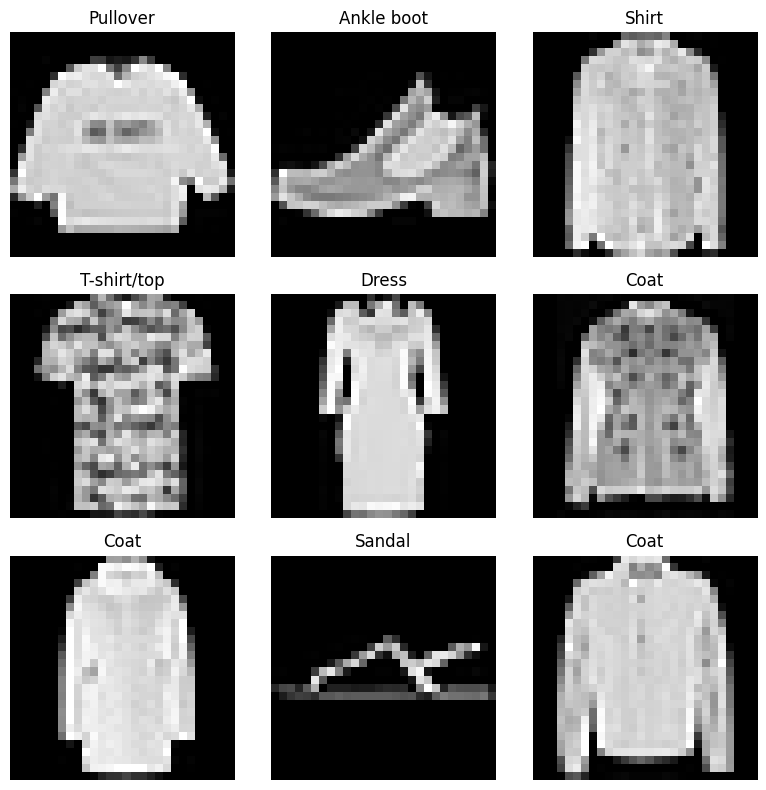

In [10]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Normalize Data


In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Reshape for CNN 

In [12]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [13]:
print("CNN Input Shape:", X_train.shape)


CNN Input Shape: (60000, 28, 28, 1)


### Build CNN Model


In [14]:
model = models.Sequential([

    # First Convolution Layer
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # Pooling Layer
    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    # Second Pooling
    layers.MaxPooling2D((2,2)),

    # Flatten Layer
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])


D:\ANACONDA\envs\lpdeeplearn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model


In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.7767 - loss: 0.6255 - val_accuracy: 0.8863 - val_loss: 0.3237
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8882 - loss: 0.3094 - val_accuracy: 0.9013 - val_loss: 0.2719
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9059 - loss: 0.2552 - val_accuracy: 0.9131 - val_loss: 0.2400
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9195 - loss: 0.2200 - val_accuracy: 0.9105 - val_loss: 0.2497
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9282 - loss: 0.1899 - val_accuracy: 0.9141 - val_loss: 0.2385
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9377 - loss: 0.1660 - val_accuracy: 0.9190 - val_loss: 0.2294
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9448 - loss: 0.1468 - val_accuracy: 0.9191 - val_loss: 0.2325
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9545 -

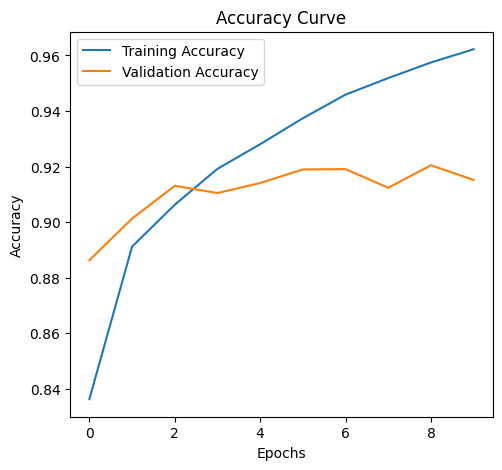

In [19]:
# Plot Accuracy Graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()


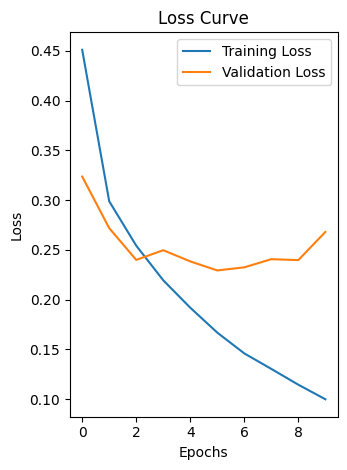

In [26]:
# Plot Loss Graph
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate Model


In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9102 - loss: 0.2871


In [21]:
print("\nTest Accuracy:", test_acc)
print("Test Loss:", test_loss)


Test Accuracy: 0.9151999950408936
Test Loss: 0.26808032393455505


### Predictions


In [22]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [23]:
# Convert probabilities to classes
y_pred_classes = np.argmax(y_pred, axis=1)


### Classification Report


In [24]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_classes,
        target_names=class_names
    )
)


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       0.98      0.99      0.98      1000
    Pullover       0.87      0.86      0.87      1000
       Dress       0.94      0.93      0.93      1000
        Coat       0.85      0.89      0.87      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.77      0.76      0.77      1000
     Sneaker       0.98      0.92      0.95      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



### Confusion Matrix


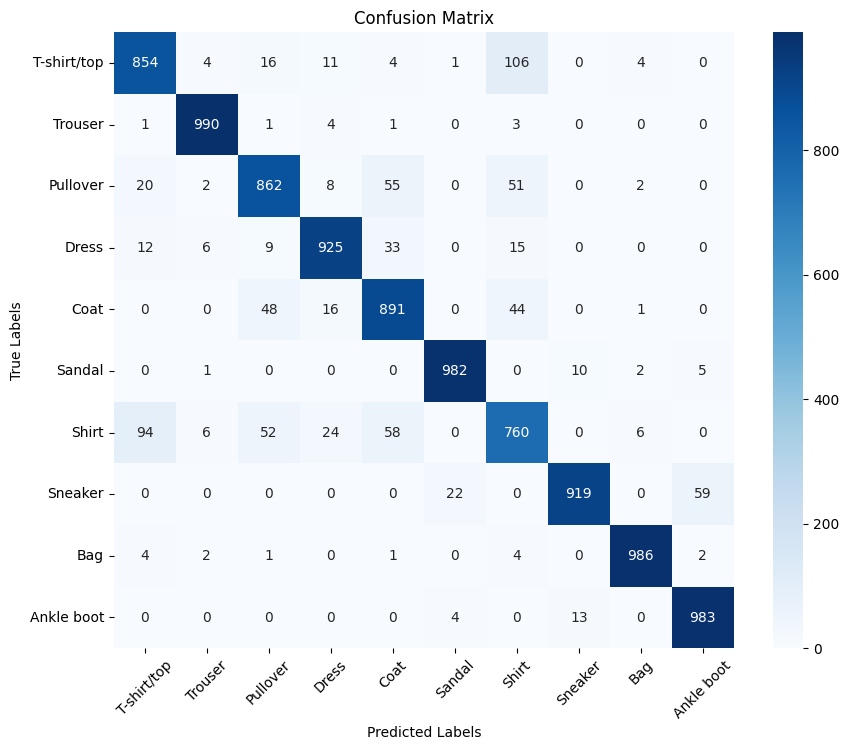

In [25]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()